# RACE Dataset — Exploratory Data Analysis
BS (CS) Spring 2026 · AI Lab Project

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

sns.set_theme(style='whitegrid')

## 1. Load Data

In [2]:
train_df = pd.read_csv('../data/raw/train.csv')
val_df   = pd.read_csv('../data/raw/val.csv')
test_df  = pd.read_csv('../data/raw/test.csv')

print('Train:', train_df.shape)
print('Val:  ', val_df.shape)
print('Test: ', test_df.shape)
train_df.head(3)

Train: (70292, 8)
Val:   (8787, 8)
Test:  (8787, 8)


,id,article,question,A,B,C,D,answer
0,high22510.txt,"Within a few short years, girls in Europe have...",The number of boy smokers is_that of girl smok...,larger than,as large as,smaller than,as small as,C
1,high18800.txt,Rats that eat high levels of a natural sugar k...,What can we learn from the passage?,The fructose-fed rats only showed changes in t...,Too much cross-linking makes the skin soft.,The amount of sugar the rats ate was larger th...,It hasn't been shown that taking in high fruct...,C
2,middle6025.txt,Today is November 8th. It's Gina's birthday. S...,--How old is Gina today? -- _ .,12,13,14,15,A


## 2. Missing Values & Data Types

In [3]:
print('=== Train null counts ===')
print(train_df.isnull().sum())
print('\n=== dtypes ===')
print(train_df.dtypes)

=== Train null counts ===
id          0
article     0
question    0
A           4
B           0
C           1
D           8
answer      0
dtype: int64

=== dtypes ===
id          object
article     object
question    object
A           object
B           object
C           object
D           object
answer      object
dtype: object


## 3. Answer Label Distribution

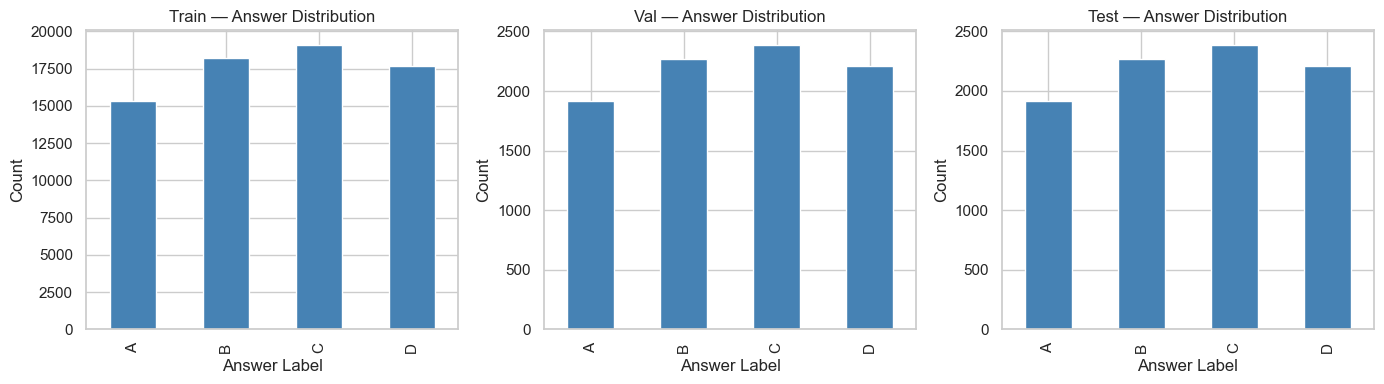

Train answer balance (%):
answer
C    27.19
B    25.86
D    25.16
A    21.79
Name: proportion, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (df, title) in zip(axes, [(train_df,'Train'),(val_df,'Val'),(test_df,'Test')]):
    df['answer'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{title} — Answer Distribution')
    ax.set_xlabel('Answer Label')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Check class balance
print('Train answer balance (%):')
print((train_df['answer'].value_counts(normalize=True) * 100).round(2))

## 4. Passage & Question Length Distribution

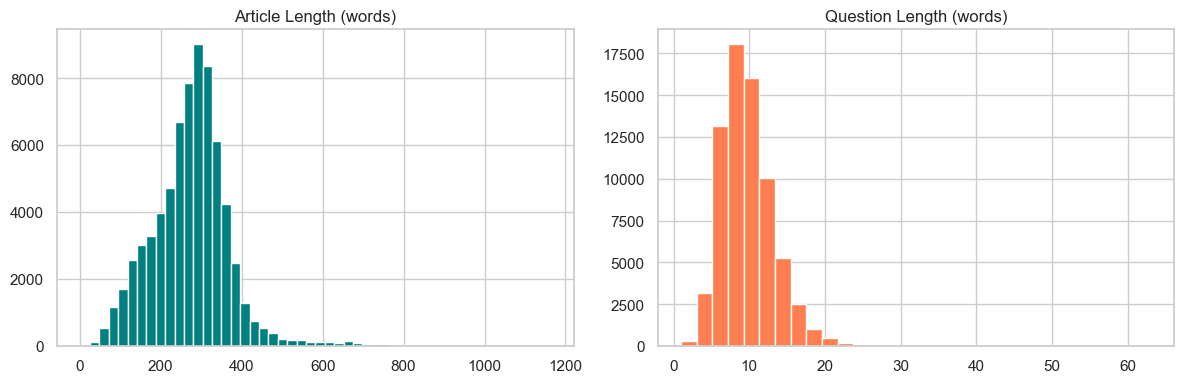

        article_len  question_len
count  70292.000000  70292.000000
mean     274.833025     10.018139
std       97.934514      3.395767
min        2.000000      1.000000
25%      216.750000      8.000000
50%      279.000000     10.000000
75%      326.000000     12.000000
max     1162.000000     63.000000


In [5]:
train_df['article_len']  = train_df['article'].str.split().str.len()
train_df['question_len'] = train_df['question'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['article_len'].hist(bins=50, ax=axes[0], color='teal')
axes[0].set_title('Article Length (words)')
train_df['question_len'].hist(bins=30, ax=axes[1], color='coral')
axes[1].set_title('Question Length (words)')
plt.tight_layout()
plt.show()

print(train_df[['article_len','question_len']].describe())

## 5. Outlier Detection

article_len: Q1=217  Q3=326  IQR=109  lower_fence=53  upper_fence=490  outliers=1758 (2.50%)
question_len: Q1=8  Q3=12  IQR=4  lower_fence=2  upper_fence=18  outliers=1296 (1.84%)


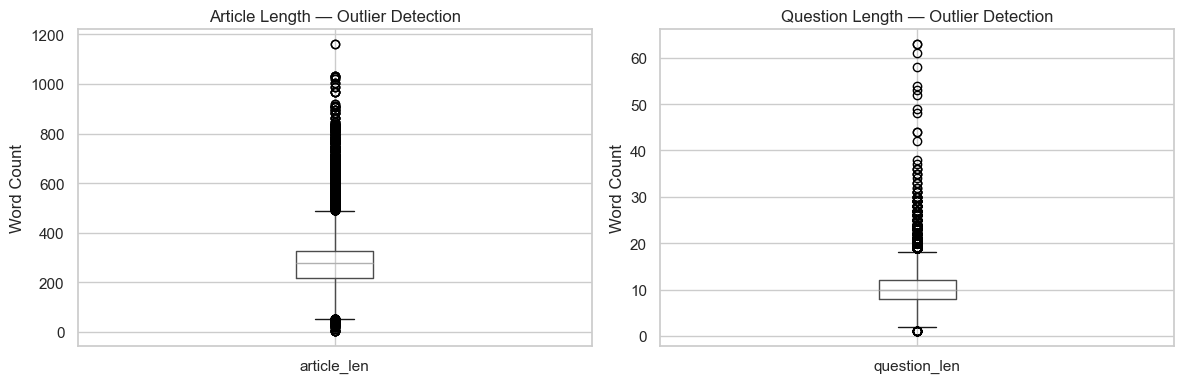


Top-5 longest articles:
       article_len  question_len answer
9723          1162            11      B
15080         1162            10      C
19174         1034            14      D
19723         1034            10      D
51754         1034            12      C

Top-5 shortest articles:
       article_len  question_len answer
11643            2            10      A
17241            2            11      C
27225            2             6      B
31369            2             9      C
38851            2             7      B


In [6]:
# IQR-based outlier detection for article and question lengths
for col in ['article_len', 'question_len']:
    Q1  = train_df[col].quantile(0.25)
    Q3  = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
    print(f'{col}: Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}  '
          f'lower_fence={lower:.0f}  upper_fence={upper:.0f}  '
          f'outliers={len(outliers)} ({len(outliers)/len(train_df)*100:.2f}%)')

# Box plots to visualise outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df.boxplot(column='article_len',  ax=axes[0], vert=True)
axes[0].set_title('Article Length — Outlier Detection')
axes[0].set_ylabel('Word Count')
train_df.boxplot(column='question_len', ax=axes[1], vert=True)
axes[1].set_title('Question Length — Outlier Detection')
axes[1].set_ylabel('Word Count')
plt.tight_layout()
plt.show()

# Show the most extreme outliers
print('\nTop-5 longest articles:')
print(train_df.nlargest(5, 'article_len')[['article_len','question_len','answer']])
print('\nTop-5 shortest articles:')
print(train_df.nsmallest(5, 'article_len')[['article_len','question_len','answer']])

## 6. Option Length Comparison

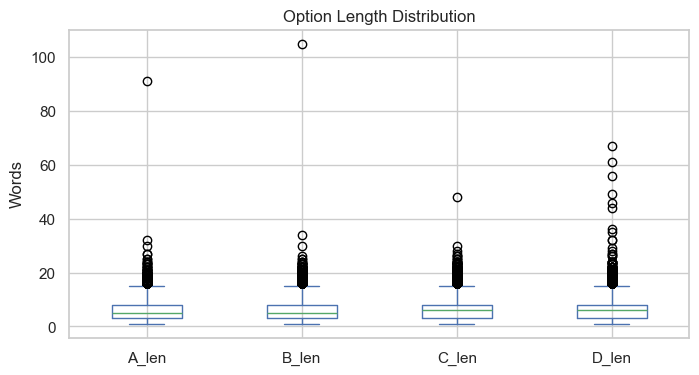

Option length statistics:
          A_len     B_len     C_len     D_len
count  70288.00  70292.00  70291.00  70284.00
mean       5.44      5.64      5.81      5.93
std        3.30      3.41      3.47      3.58
min        1.00      1.00      1.00      1.00
25%        3.00      3.00      3.00      3.00
50%        5.00      5.00      6.00      6.00
75%        8.00      8.00      8.00      8.00
max       91.00    105.00     48.00     67.00


In [7]:
for opt in ['A','B','C','D']:
    train_df[f'{opt}_len'] = train_df[opt].str.split().str.len()

opt_lens = train_df[['A_len','B_len','C_len','D_len']]
opt_lens.plot(kind='box', figsize=(8,4), title='Option Length Distribution')
plt.ylabel('Words')
plt.show()

print('Option length statistics:')
print(opt_lens.describe().round(2))

## 7. Correlation Analysis

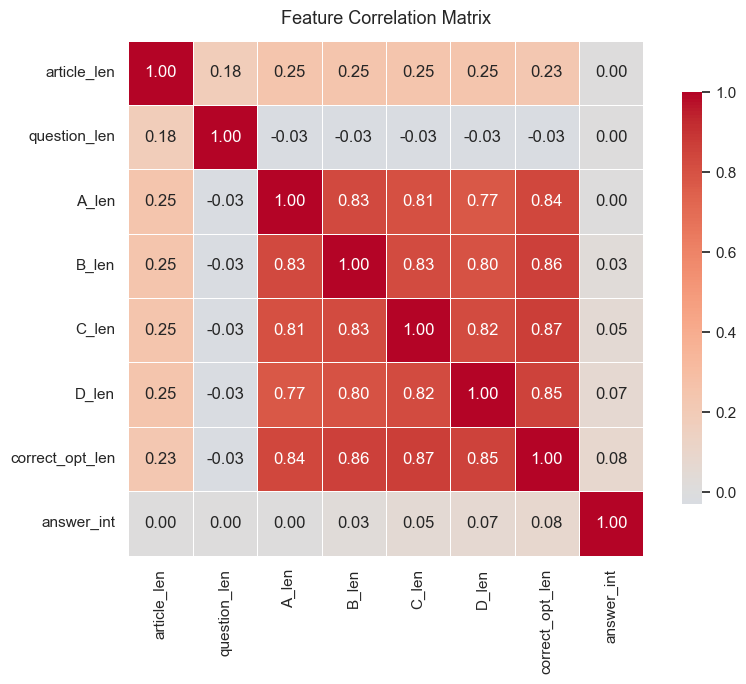


Correlation with answer_int (label):
correct_opt_len    0.082455
D_len              0.067425
C_len              0.054354
B_len              0.031189
A_len              0.004413
question_len       0.002727
article_len        0.002526
Name: answer_int, dtype: float64


In [8]:
# Encode answer label as integer (A=0, B=1, C=2, D=3) for correlation
train_df['answer_int'] = train_df['answer'].map({'A':0,'B':1,'C':2,'D':3})

# Compute correct option length (length of the correct answer option)
train_df['correct_opt_len'] = train_df.apply(
    lambda r: len(str(r[r['answer']]).split()), axis=1
)

# Feature correlation matrix
corr_cols = ['article_len', 'question_len', 'A_len', 'B_len', 'C_len', 'D_len',
             'correct_opt_len', 'answer_int']
corr_matrix = train_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print('\nCorrelation with answer_int (label):')
print(corr_matrix['answer_int'].drop('answer_int').sort_values(key=abs, ascending=False))

## 8. Feature Relationship Analysis

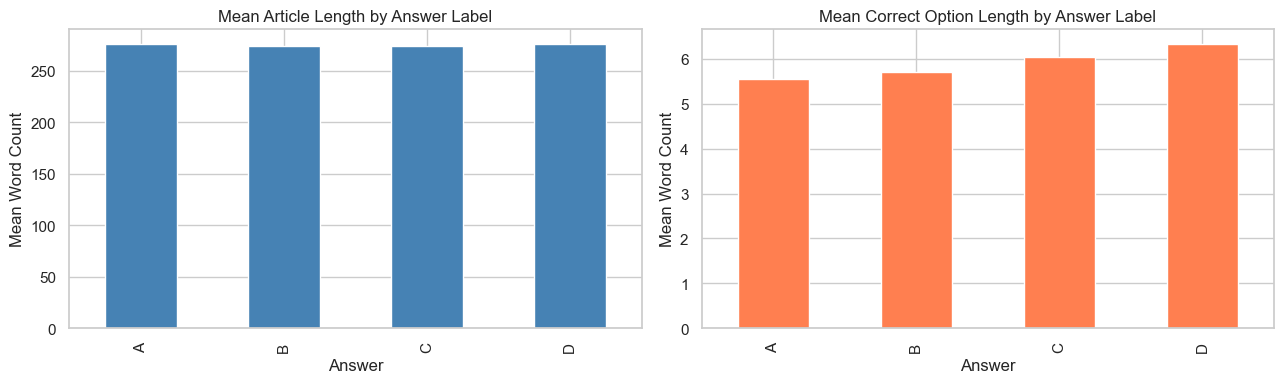

In [9]:
# Article length vs answer label — do longer articles favour certain answers?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

train_df.groupby('answer')['article_len'].mean().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title('Mean Article Length by Answer Label')
axes[0].set_xlabel('Answer')
axes[0].set_ylabel('Mean Word Count')

train_df.groupby('answer')['correct_opt_len'].mean().plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title('Mean Correct Option Length by Answer Label')
axes[1].set_xlabel('Answer')
axes[1].set_ylabel('Mean Word Count')

plt.tight_layout()
plt.show()

## 9. Top-20 Most Frequent Words in Questions

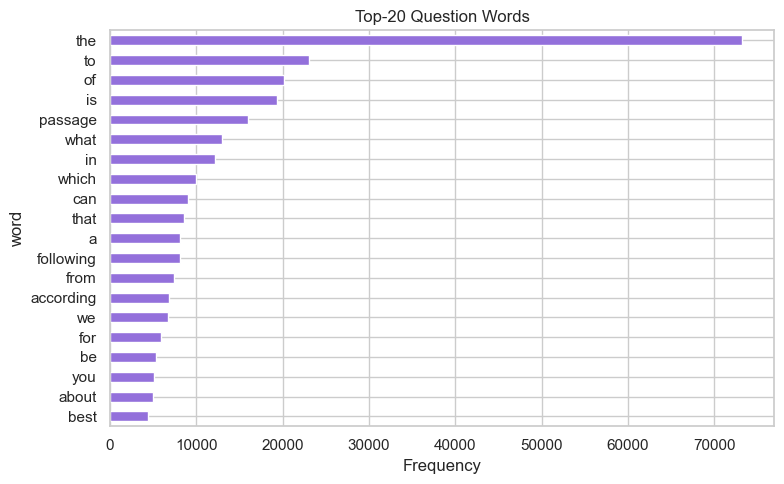

In [10]:
from collections import Counter
import re

all_q_words = ' '.join(train_df['question'].dropna()).lower()
all_q_words = re.sub(r'[^a-z\s]', '', all_q_words)
freq = Counter(all_q_words.split())
common = pd.DataFrame(freq.most_common(20), columns=['word','count'])

common.plot(kind='barh', x='word', y='count', figsize=(8,5),
            title='Top-20 Question Words', legend=False, color='mediumpurple')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Summary Statistics Table

In [11]:
summary = pd.DataFrame({
    'Split':    ['Train', 'Val', 'Test'],
    'Rows':     [len(train_df), len(val_df), len(test_df)],
    'Avg Article Len': [
        train_df['article'].str.split().str.len().mean(),
        val_df['article'].str.split().str.len().mean(),
        test_df['article'].str.split().str.len().mean(),
    ],
    'Avg Question Len': [
        train_df['question'].str.split().str.len().mean(),
        val_df['question'].str.split().str.len().mean(),
        test_df['question'].str.split().str.len().mean(),
    ],
    'Answer Balance (A%)': [
        (train_df['answer'] == 'A').mean() * 100,
        (val_df['answer'] == 'A').mean() * 100,
        (test_df['answer'] == 'A').mean() * 100,
    ],
}).round(1)
print(summary.to_string(index=False))
summary

Split  Rows  Avg Article Len  Avg Question Len  Answer Balance (A%)
Train 70292            274.8              10.0                 21.8
  Val  8787            276.3              10.0                 21.8
 Test  8787            274.8              10.0                 21.8


,Split,Rows,Avg Article Len,Avg Question Len,Answer Balance (A%)
0,Train,70292,274.8,10.0,21.8
1,Val,8787,276.3,10.0,21.8
2,Test,8787,274.8,10.0,21.8
